In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import numpy as np

In [131]:
# Load the dataset
data = pd.read_csv('D:/DataBlueSky US/OneDrive - DataBlueSky/Learnings/Berkley/ML/CapStonePorject_NicoleHertel/Technical Support Dataset.csv')
data = data.drop(['Ticket ID', 'Longitude', 'Latitude','Created time', 'Expected SLA to resolve', 'Expected SLA to resolve', 'First response time', 'Close time', 'Resolution time', 'Expected SLA to first response'], axis=1)
data

,Status,Priority,Source,Topic,Agent Group,Agent Name,SLA For first response,SLA For Resolution,Agent interactions,Survey results,Product group,Support Level,Country,Good_Solved
0,Closed,Low,Email,Feature request,1st line support,Kristos Westoll,Within SLA,Within SLA,1.0,3.0,Custom software development,Tier 1,Republic of Ireland,1
1,In progress,High,Phone,Product setup,2nd line support,Adolpho Messingham,Within SLA,SLA Violated,3.0,NaN,Other,Tier 2,Italy,0
2,Resolved,Low,Chat,Purchasing and invoicing,1st line support,Bernard Beckley,Within SLA,Within SLA,2.0,NaN,Custom software development,Tier 1,Austria,0
3,Closed,Medium,Email,Pricing and licensing,1st line support,Connor Danielovitch,SLA Violated,Within SLA,10.0,4.0,Ready to use Software,Tier 1,Spain,1
4,Closed,Low,Email,Product setup,1st line support,Kristos Westoll,Within SLA,Within SLA,1.0,2.0,Other,Tier 1,Austria,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2325,Resolved,Low,Email,Product setup,1st line support,Connor Danielovitch,Within SLA,Within SLA,1.0,NaN,Ready to use Software,Tier 1,Spain,0
2326,Resolved,Medium,Email,Pricing and licensing,1st line support,Connor Danielovitch,Within SLA,Within SLA,1.0,NaN,Custom software development,Tier 1,Slovenia,0
2327,Resolved,High,Email,Feature request,2nd line support,Michele Whyatt,Within SLA,SLA Violated,1.0,NaN,Other,Tier 2,Republic of Ireland,0
2328,Resolved,Low,Email,Product setup,1st line support,Kristos Westoll,Within SLA,Within SLA,10.0,NaN,Custom software development,Tier 1,Republic of Ireland,0


In [133]:
# Encode categorical variables
categorical_cols = ['Product group', 'Support Level', 'Priority', 'Source', 'Status', 'Country', 'Topic', 'Agent Group', 'Agent Name', 'Status', 'SLA For first response',  'SLA For Resolution']
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

data.fillna(data.median(), inplace=True)
X = data.drop('Good_Solved', axis=1)
y = data['Good_Solved']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [135]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}


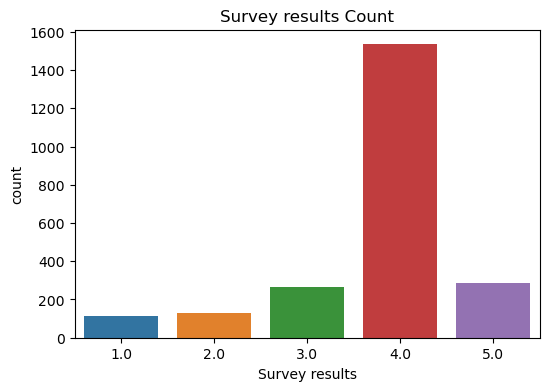

In [137]:
# Survey results plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Survey results', data=data)
plt.title('Survey results Count')
plt.show()

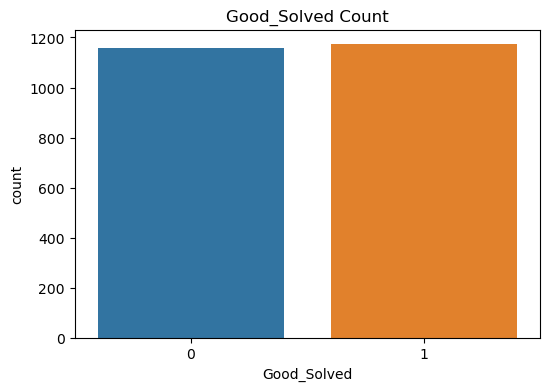

In [139]:
# Good_Solved plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Good_Solved', data=data)
plt.title('Good_Solved Count')
plt.show()

C:\Users\NicoleHertel\AppData\Local\Temp\ipykernel_31288\3143218092.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, result], ignore_index=True)


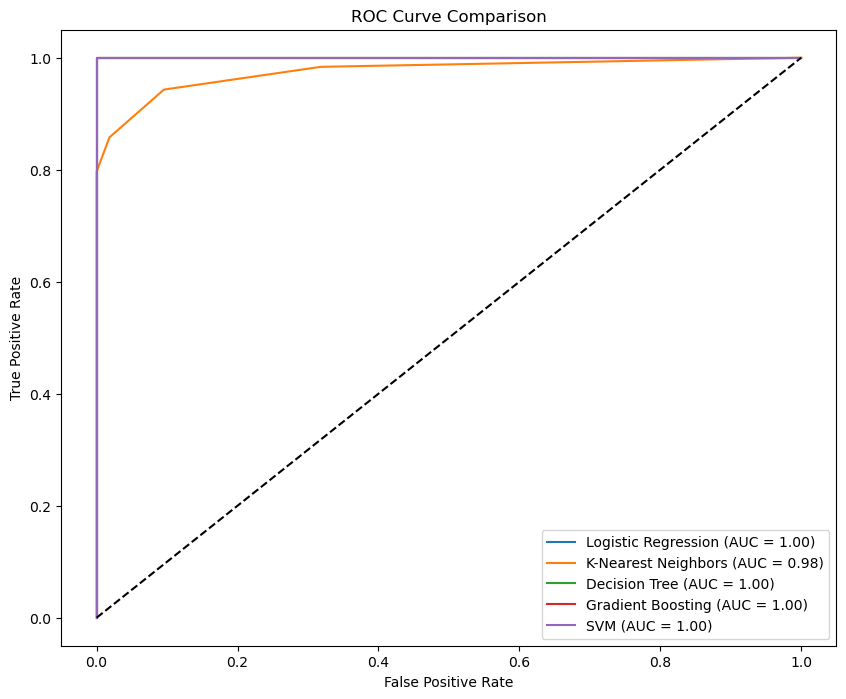

In [117]:
# Training models and evaluating
results = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"])
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
     
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred) #, average='weighted')
    recall = recall_score(y_test, y_pred) #, average='weighted')
    f1 = f1_score(y_test, y_pred) #, average='weighted')
    auc_roc = roc_auc_score(y_test, y_pred_proba) # multi_class='ovr')
    
    # Store results
    result = pd.DataFrame([[model_name, accuracy, precision, recall, f1, auc_roc]],
                          columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"])
    results = pd.concat([results, result], ignore_index=True)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba) #, pos_label='your_label')
 
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_roc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

In [143]:
# Feature Importance (for Gradient Boosting and Decision Tree)
for model_name, model in models.items():
    if hasattr(model, "feature_importances_"):
        plt.figure(figsize=(10, 6))
        feature_importance = model.feature_importances_
        sorted_idx = np.argsort(feature_importance)
        plt.barh(X.columns[sorted_idx], feature_importance[sorted_idx])
        plt.title(f"{model_name} Feature Importances")
        plt.xlabel("Importance")
        plt.show()

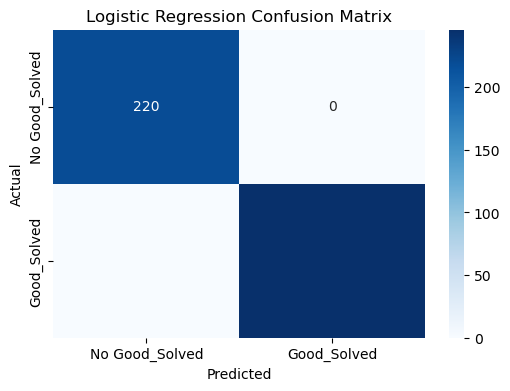

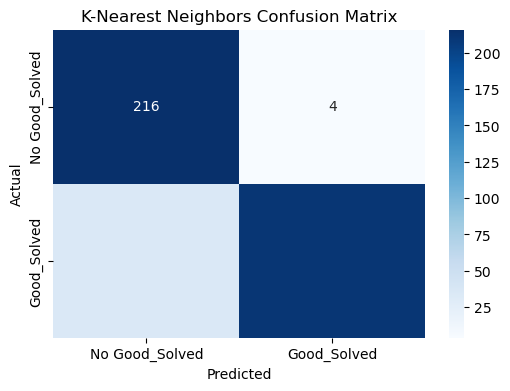

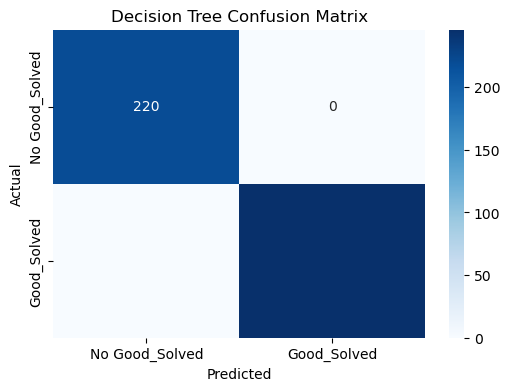

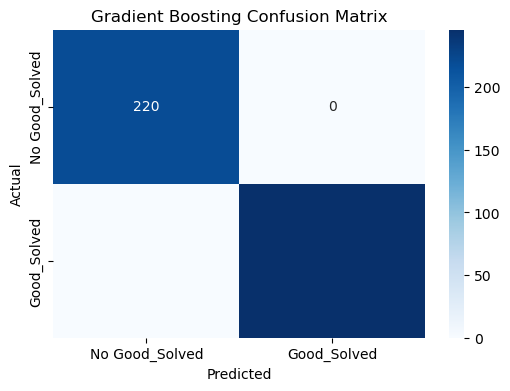

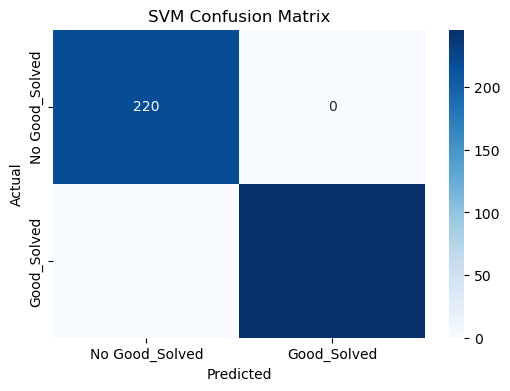

In [125]:
# Confusion Matrix for each model
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Good_Solved", "Good_Solved"], yticklabels=["No Good_Solved", "Good_Solved"])
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [123]:
# Display results table
print(results)

                 Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  Logistic Regression  1.000000   1.000000  1.000000  1.000000  1.000000
1  K-Nearest Neighbors  0.916309   0.981395  0.857724  0.915401  0.975471
2        Decision Tree  1.000000   1.000000  1.000000  1.000000  1.000000
3    Gradient Boosting  1.000000   1.000000  1.000000  1.000000  1.000000
4                  SVM  1.000000   1.000000  1.000000  1.000000  1.000000
